# Day Low Distribution - Analytics

### Import Library

In [1]:
import numpy as np
import pandas as pd
import numpy as np
import pandas_ta as ta
import seaborn as sns

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 120
import warnings
warnings.filterwarnings('ignore')

### Load Price Data

In [ ]:
import os
from pathlib import Path
notebook_path = os.getcwd()
current_dir = Path(notebook_path)
csv_file = str(current_dir) + '/VN30F1M_5minutes.csv'
is_file = os.path.isfile(csv_file)
if is_file:
    dataset = pd.read_csv(csv_file, index_col='Date', parse_dates=True)
else:
    print('remote')
    dataset = pd.read_csv("https://raw.githubusercontent.com/zuongthaotn/vn-stock-data/main/VN30ps/VN30F1M_5minutes.csv", index_col='Date', parse_dates=True)

In [3]:
data = dataset.copy()

In [4]:
data = data[(data.index > '2020-01-01 00:00:00') & (data.index < '2025-01-01 00:00:00')]
# Phan tich du lieu lich su, du lieu 2025 de test, du lieu truoc 2020 qua so khai

In [5]:
data

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02 09:00:00,877.5,877.6,877.1,877.3,1434
2020-01-02 09:05:00,877.3,877.5,877.2,877.4,306
2020-01-02 09:10:00,877.4,877.7,877.4,877.6,476
2020-01-02 09:15:00,877.6,877.6,876.6,876.8,796
2020-01-02 09:20:00,876.9,877.7,876.7,877.6,904
...,...,...,...,...,...
2024-12-31 14:15:00,1347.4,1347.5,1345.4,1345.5,5691
2024-12-31 14:20:00,1345.4,1346.0,1344.5,1345.6,5756
2024-12-31 14:25:00,1345.6,1346.7,1345.0,1345.8,4219


In [6]:
tmp_data = dataset.copy()
tmp_data['DayLow'] = tmp_data['Low']
daily_data = tmp_data.resample('D').agg({
        'DayLow': 'min'
    })
daily_data.dropna(subset=['DayLow'], inplace=True)

In [7]:
data = data.assign(time_d=pd.PeriodIndex(data.index, freq='1D').to_timestamp())

In [8]:
merged_data = pd.merge(data, daily_data, left_on="time_d", right_index=True, how="left")

In [9]:
merged_data

,Open,High,Low,Close,Volume,time_d,DayLow
Date,,,,,,,
2020-01-02 09:00:00,877.5,877.6,877.1,877.3,1434,2020-01-02,876.6
2020-01-02 09:05:00,877.3,877.5,877.2,877.4,306,2020-01-02,876.6
2020-01-02 09:10:00,877.4,877.7,877.4,877.6,476,2020-01-02,876.6
2020-01-02 09:15:00,877.6,877.6,876.6,876.8,796,2020-01-02,876.6
2020-01-02 09:20:00,876.9,877.7,876.7,877.6,904,2020-01-02,876.6
...,...,...,...,...,...,...,...
2024-12-31 14:15:00,1347.4,1347.5,1345.4,1345.5,5691,2024-12-31,1344.5
2024-12-31 14:20:00,1345.4,1346.0,1344.5,1345.6,5756,2024-12-31,1344.5
2024-12-31 14:25:00,1345.6,1346.7,1345.0,1345.8,4219,2024-12-31,1344.5


## Data Analytics

In [10]:
merged_data['hour'] = merged_data.index.hour
merged_data['minute'] = merged_data.index.minute
merged_data['prev_High'] = merged_data['High'].shift(1)
merged_data['prev_Low'] = merged_data['Low'].shift(1)
merged_data['prev_Close'] = merged_data['Close'].shift(1)
merged_data['prev_Open'] = merged_data['Open'].shift(1)
merged_data['prev_Vol'] = merged_data['Volume'].shift(1)

### Giá thường kéo đến phần thập phân nào

<Axes: xlabel='frac', ylabel='Count'>

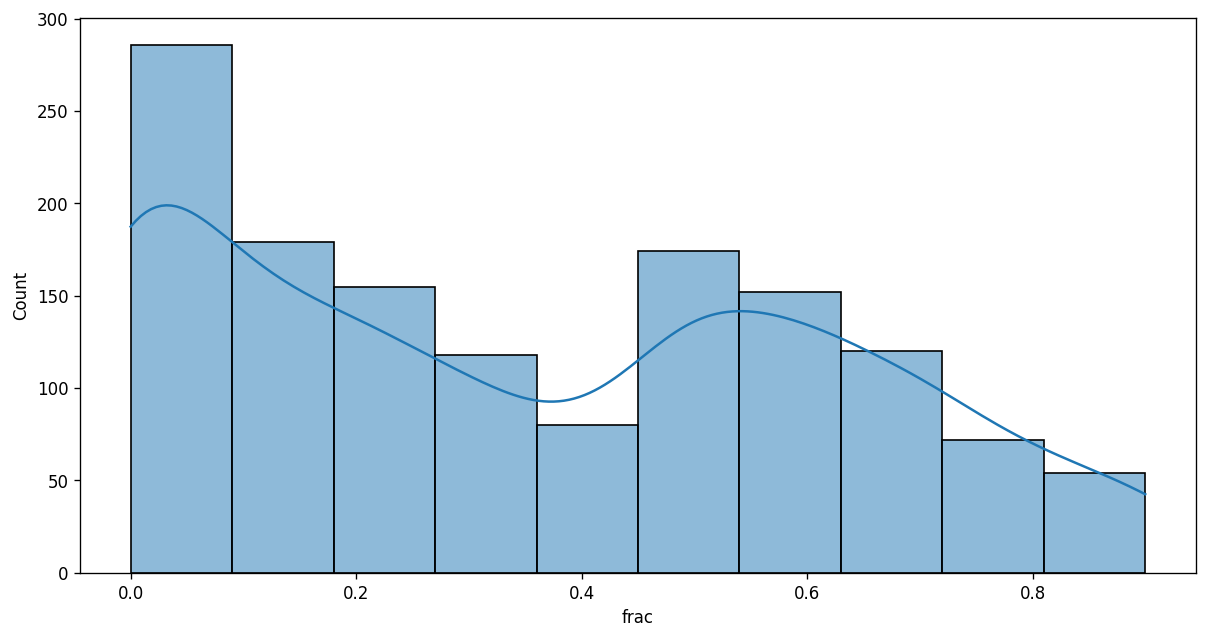

In [11]:
import math
def get_frac(r):
    frac, integer = math.modf(r["Low"])
    return frac
ana_data = merged_data.copy()
ana_data = ana_data[ana_data.Low == ana_data.DayLow]
ana_data['frac'] = ana_data.apply(lambda r: get_frac(r), axis=1)
sns.histplot(ana_data["frac"], bins=10, kde=True)

### Tôi muốn biết body trung bình sẽ tăng hay giảm

Text(0.5, 1.0, 'Tỉ lệ body height avg tăng / giảm so với trước đó khi tạo đáy')

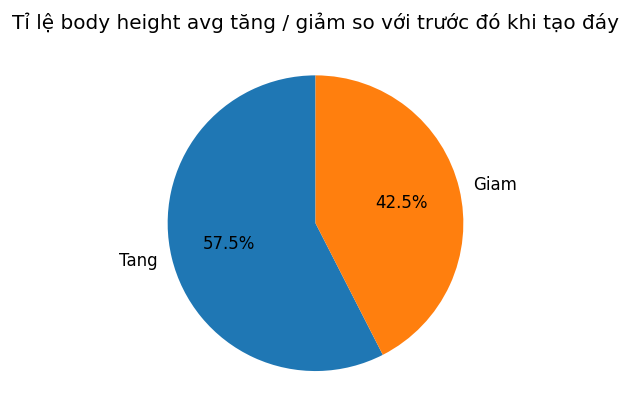

In [13]:
ana_data = merged_data.copy()
ana_data['body'] = ana_data.apply(lambda r: abs(r["Close"] - r["Open"]), axis=1)
ana_data['body_avg'] = ana_data['body'].rolling(20).mean()
ana_data['prev_body_avg'] = ana_data['body_avg'].shift(1)
ana_data.dropna(inplace=True)
ana_data = ana_data[ana_data.Low == ana_data.DayLow]
ana_data['body_avg_group'] = ana_data.apply(lambda r: "Tang" if r["body_avg"] > r["prev_body_avg"] else "Giam", axis=1)
counts = ana_data['body_avg_group'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ body height avg tăng / giảm so với trước đó khi tạo đáy")

### Day-Low is min_3

Text(0.5, 1.0, 'Tỉ lệ Day-Low is is_min_range khi tạo đáy')

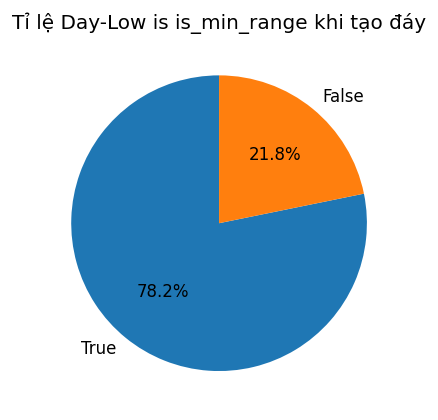

In [53]:
ana_data = merged_data.copy()
ana_data['is_min_range'] = (ana_data["Low"] < ana_data["Low"].shift(1).rolling(5).min())
ana_data.dropna(inplace=True)
ana_data = ana_data[ana_data.Low == ana_data.DayLow]
counts = ana_data['is_min_range'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ Day-Low is is_min_range khi tạo đáy")

### Tôi muốn biết mqh giữa giá Close và body nến như nào?

Text(0.5, 1.0, 'Tỉ lệ tạo đáy theo group (Price vs Body)')

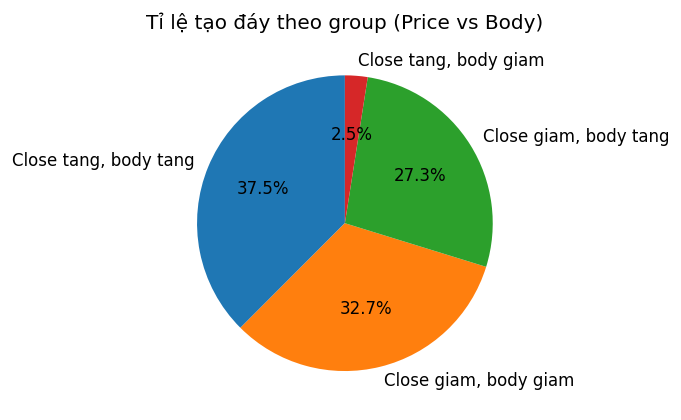

In [15]:
def get_ibs_vol_group(r):
    if r["Close"] > r["prev_Close"] and r["body"] > r["prev_body"]:
        return "Close tang, body tang"
    if r["Close"] > r["prev_Close"] and r["body"] < r["prev_body"]:
        return "Close tang, body giam"
    if r["Close"] < r["prev_Close"] and r["body"] > r["prev_body"]:
        return "Close giam, body tang"
    if r["Close"] < r["prev_Close"] and r["body"] < r["prev_body"]:
        return "Close giam, body giam"
ana_data = merged_data.copy()
ana_data['body'] = ana_data.apply(lambda r: r["Close"] - r["Open"], axis=1)
ana_data['prev_body'] = ana_data['body'].shift(1)
ana_data.dropna(inplace=True)
ana_data = ana_data[ana_data.Low == ana_data.DayLow]
ana_data["price_vs_body_group"] = ana_data.apply(lambda r: get_ibs_vol_group(r) , axis=1)
counts = ana_data['price_vs_body_group'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ tạo đáy theo group (Price vs Body)")


### Tôi muốn biết sự phân phối của độ dài bóng nến và cây nến

In [16]:
ana_data = merged_data.copy()
ana_data['lower_shadow'] = ana_data.apply(lambda r: min(r["Open"], r["Close"]) - r["Low"], axis=1)
ana_data['candlestick_height'] = ana_data.apply(lambda r: r["High"] - r["Low"], axis=1)
ana_data['prev_lower_shadow'] = ana_data['lower_shadow'].shift(1)
ana_data.dropna(inplace=True)
ana_data = ana_data[ana_data.Low == ana_data.DayLow]
ana_data = ana_data[ana_data.High != ana_data.Low]

<Axes: xlabel='shadow_on_length', ylabel='Count'>

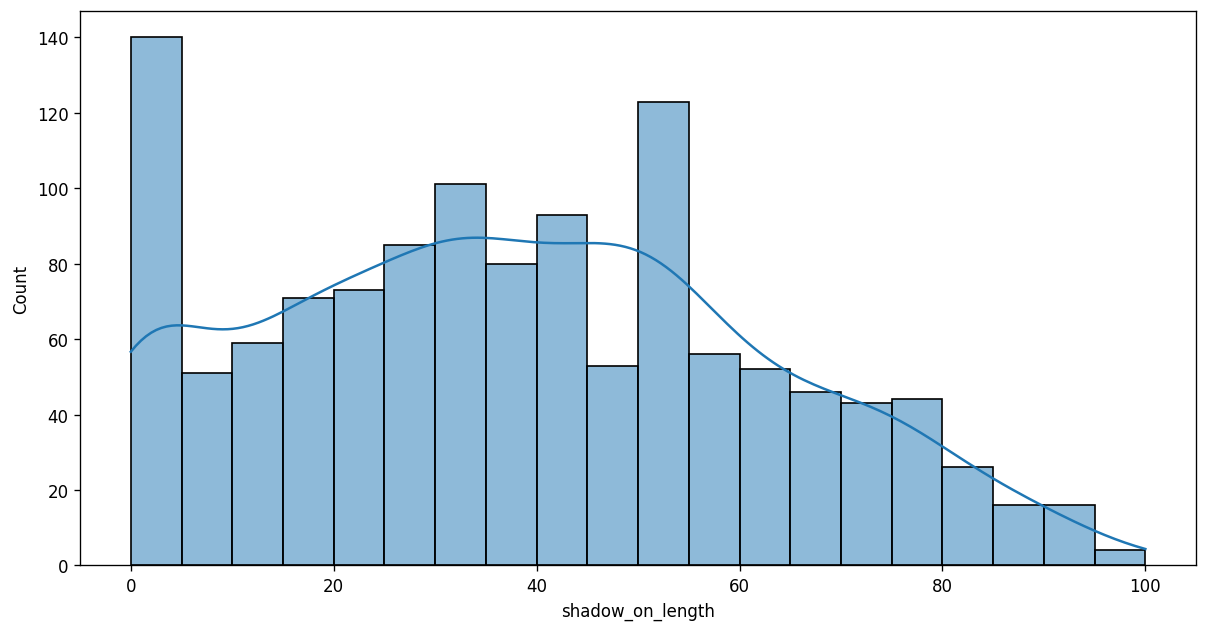

In [17]:
ana_data['shadow_on_length'] = ana_data.apply(lambda r: round(r["lower_shadow"] * 100 / r["candlestick_height"], 3), axis=1)
sns.histplot(ana_data["shadow_on_length"], bins=20, kde=True)

<Axes: xlabel='body', ylabel='Count'>

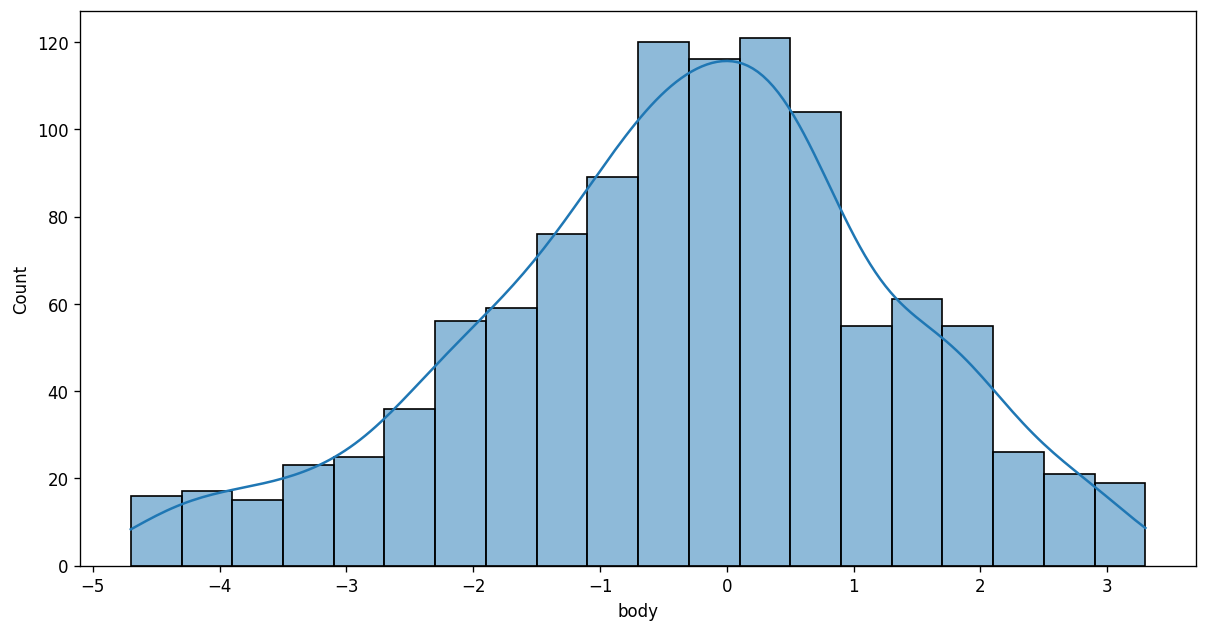

In [18]:
ana_data['body'] = ana_data.apply(lambda r: r["Close"] - r["Open"], axis=1)
lower = ana_data["body"].quantile(0.05)
upper = ana_data["body"].quantile(0.95)
filtered = ana_data[(ana_data["body"] <= upper) & (ana_data["body"] >= lower)]
sns.histplot(filtered["body"], bins=20, kde=True)

### [✔] Tôi muốn biết bóng nến tăng hay giảm khi Market tạo đáy

Text(0.5, 1.0, 'Tỉ lệ (râu nến tăng hay giảm so với cây nến trước đó) khi tạo đáy')

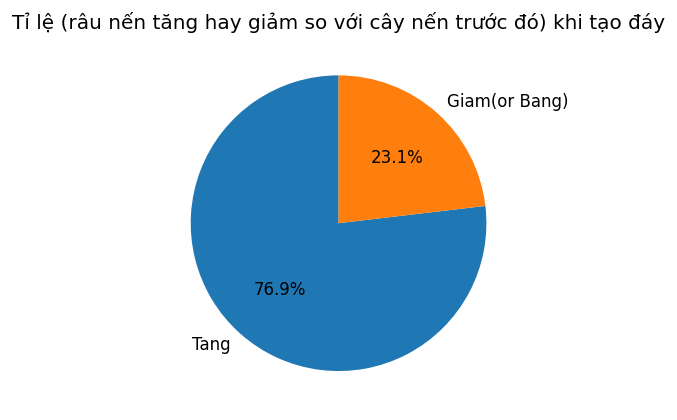

In [19]:
ana_data['lower_shadow_group'] = ana_data.apply(lambda r: "Tang" if r["lower_shadow"] > r["prev_lower_shadow"] else "Giam(or Bang)", axis=1)
counts = ana_data['lower_shadow_group'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ (râu nến tăng hay giảm so với cây nến trước đó) khi tạo đáy")

### Tôi muốn biết MFI sẽ có phân phối như nào

In [23]:
ana_data = merged_data.copy()
ana_data["MFI_1d"] = ta.mfi(
    high=ana_data["High"],
    low=ana_data["Low"],
    close=ana_data["Close"],
    volume=ana_data["Volume"],
    length=50
)
ana_data["MFI_3d"] = ta.mfi(
    high=ana_data["High"],
    low=ana_data["Low"],
    close=ana_data["Close"],
    volume=ana_data["Volume"],
    length=150
)
ana_data["prev_MFI_1d"] = ana_data["MFI_1d"].shift(1)
ana_data.dropna(inplace=True)
ana_data = ana_data[ana_data.Low == ana_data.DayLow]

Text(0.5, 1.0, 'MFI Distribution at valley')

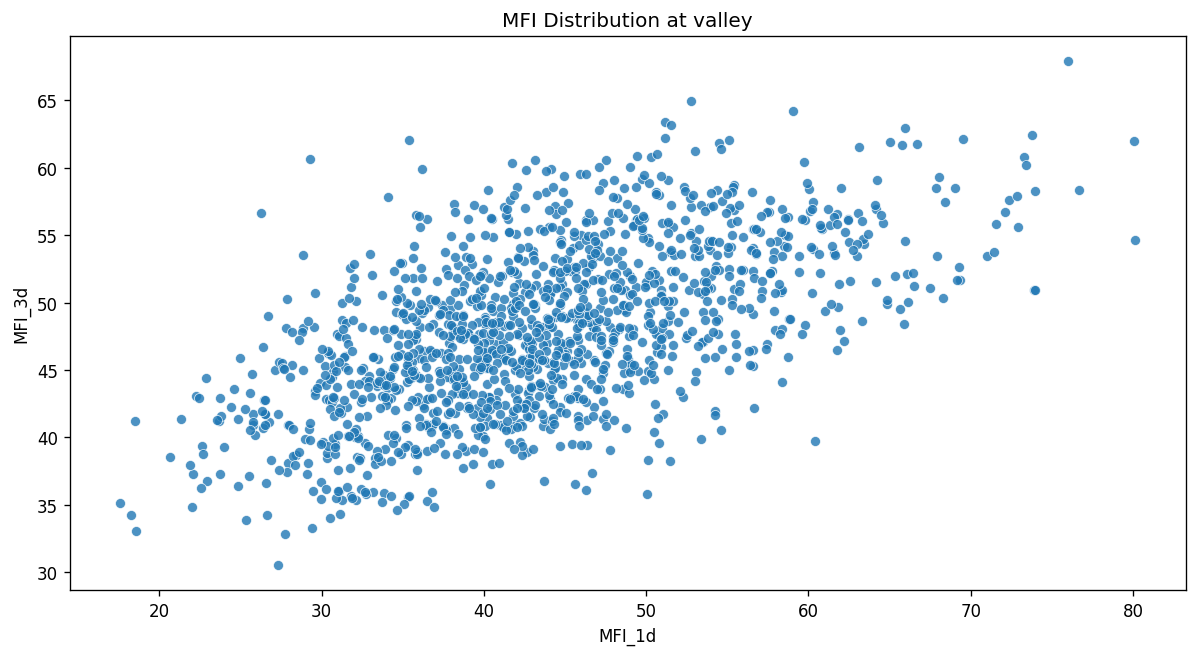

In [24]:
sns.scatterplot(
    data=ana_data[['MFI_1d', 'MFI_3d']],
    x='MFI_1d',
    y='MFI_3d',
    alpha=0.8
)
plt.title('MFI Distribution at valley')

### [✔] Tôi muốn biết MFI sẽ tăng hay giảm

Text(0.5, 1.0, 'Tỉ lệ (MFI sẽ tăng hay giảm so với cây nến trước đó)')

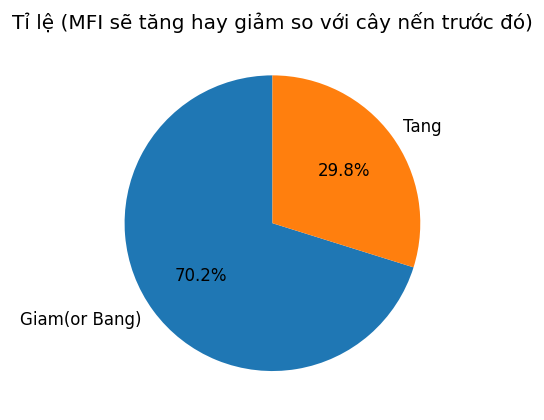

In [25]:
ana_data['MFI_group'] = ana_data.apply(lambda r: "Tang" if r["MFI_1d"] > r["prev_MFI_1d"] else "Giam(or Bang)", axis=1)
ana_data.dropna(inplace=True)
counts = ana_data['MFI_group'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ (MFI sẽ tăng hay giảm so với cây nến trước đó)")

### [✔] Group (ibs, volume) nào

In [26]:
def get_ibs_vol_group(r):
    if r["Volume"] > r["prev_Vol"] and r["ibs"] > r["prev_ibs"]:
        return "Vol up, ibs incre"
    if r["Volume"] > r["prev_Vol"] and r["ibs"] < r["prev_ibs"]:
        return "Vol up, ibs decr"
    if r["Volume"] < r["prev_Vol"] and r["ibs"] > r["prev_ibs"]:
        return "Vol down, ibs incre"
    if r["Volume"] < r["prev_Vol"] and r["ibs"] < r["prev_ibs"]:
        return "Vol down, ibs decr"

Text(0.5, 1.0, 'Tỉ lệ tạo đỉnh theo group')

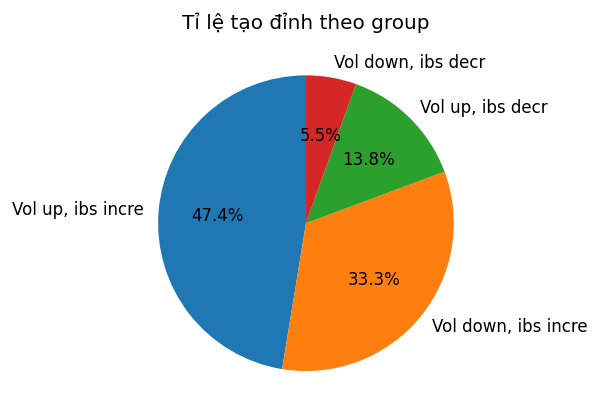

In [27]:
ana_data = merged_data.copy()
ana_data['ibs'] = ana_data.apply(lambda r: 0 if r["High"] == r["Low"] else (r["Close"] - r["Low"]) / (r["High"] - r["Low"]), axis=1)
ana_data['prev_ibs'] = ana_data['ibs'].shift(1)
ana_data.dropna(inplace=True)
ana_data = ana_data[ana_data.Low == ana_data.DayLow]
ana_data = ana_data[ana_data.High != ana_data.Low]
ana_data["ibs_vol_group"] = ana_data.apply(lambda r: get_ibs_vol_group(r) , axis=1)
counts = ana_data['ibs_vol_group'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ tạo đỉnh theo group")

<Axes: xlabel='ibs', ylabel='Count'>

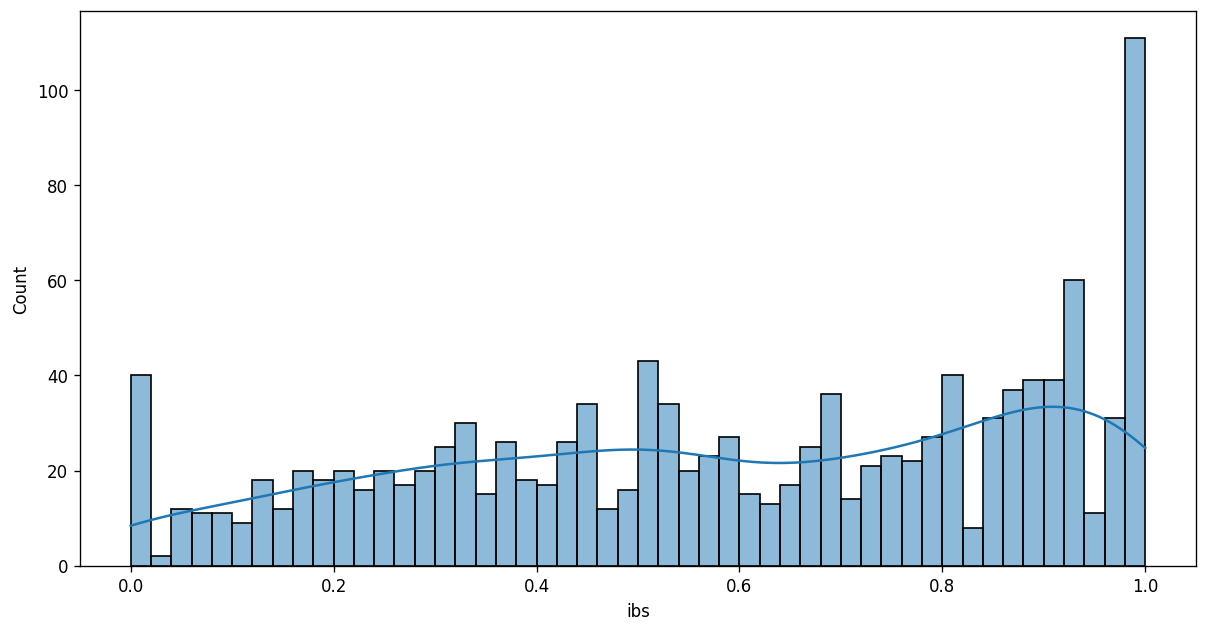

In [28]:
ana_data['ibs'] = ana_data['ibs'].round(2)
sns.histplot(ana_data["ibs"], bins=50, kde=True)

### [✔] Tôi muốn biết Market thường tạo đáy vào giờ nào?

<Axes: xlabel='hour'>

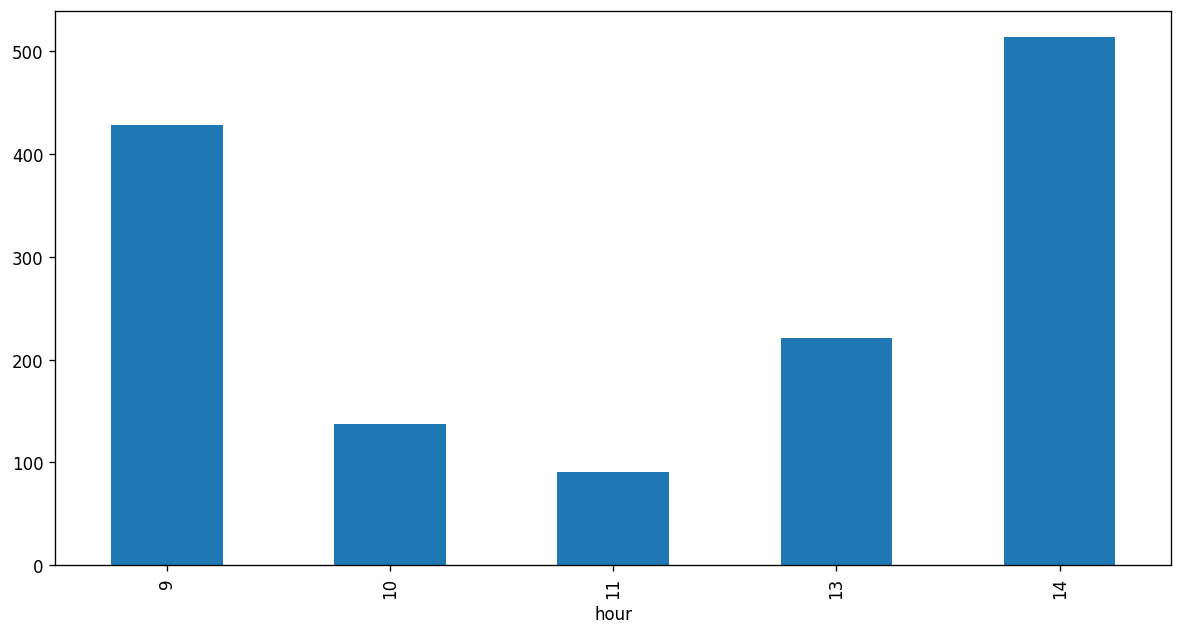

In [29]:
ana_data = merged_data.copy()
ana_data.dropna(inplace=True)
ana_data = ana_data[ana_data.Low == ana_data.DayLow]
group_by_hour = ana_data.groupby(['hour'])['hour'].count().rename({'hour': 'count'})
group_by_hour.plot.bar()

Text(0.5, 1.0, 'Tỉ lệ thời gian tạo đáy theo giờ')

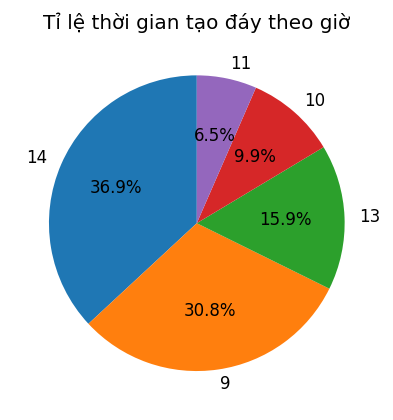

In [30]:
counts = ana_data['hour'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ thời gian tạo đáy theo giờ")

### [✔] Tôi muốn biết Market thường tạo đáy vào phút nào?

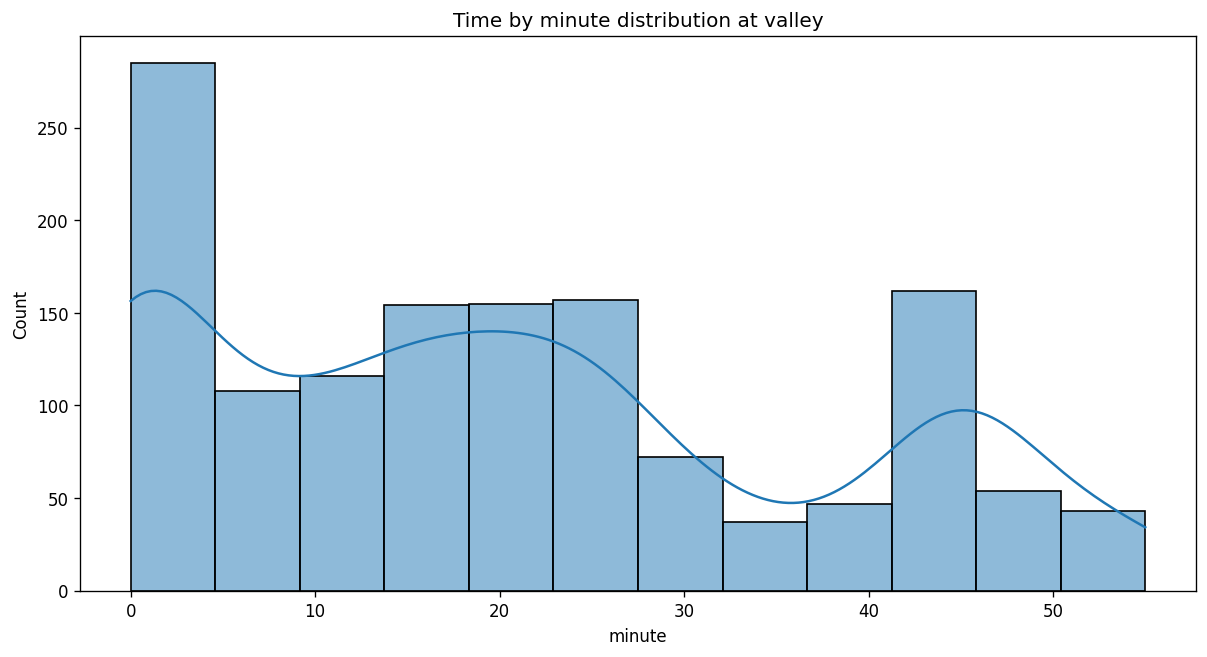

In [31]:
ana_data = merged_data.copy()
ana_data.dropna(inplace=True)
ana_data = ana_data[ana_data.Low == ana_data.DayLow]
sns.histplot(ana_data['minute'], bins=12, kde=True)
plt.title('Time by minute distribution at valley')
plt.show()

### Tôi muốn biết Market thường tạo đáy tại nến xanh hay đỏ?

Text(0.5, 1.0, 'Tỉ lệ màu nến khi tạo đáy')

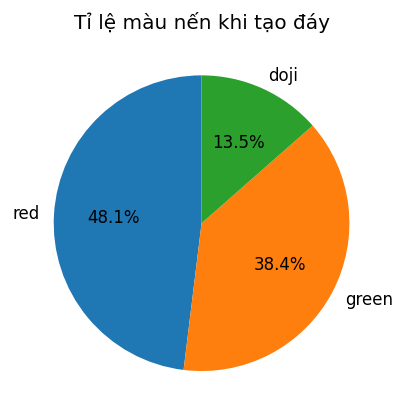

In [32]:
ana_data = merged_data.copy()
ana_data.dropna(inplace=True)
ana_data = ana_data[ana_data.Low == ana_data.DayLow]
ana_data['color'] = ana_data.apply(lambda r: 'doji' if r["Open"] == r["Close"] else ('green' if r["Open"] < r["Close"] else 'red'), axis=1)
counts = ana_data['color'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ màu nến khi tạo đáy")

### Tôi muốn biết Market thường tạo đáy sau nến xanh hay đỏ?

Text(0.5, 1.0, 'Tỉ lệ tạo đáy sau nến xanh hay đỏ')

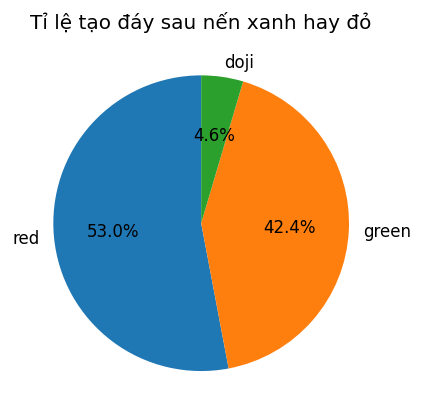

In [33]:
# Remove special time
ana_data = ana_data[(100 * ana_data.index.hour + ana_data.index.minute != 1130) & (100 * ana_data.index.hour + ana_data.index.minute != 1430) & (100 * ana_data.index.hour + ana_data.index.minute != 1445)]
ana_data['prev_color'] = ana_data['color'].shift(1)
ana_data.dropna(inplace=True)
counts = ana_data['prev_color'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ tạo đáy sau nến xanh hay đỏ")

### Bộ 3 cây nến tại đáy

Text(0.5, 1.0, 'Bộ 3 cây nến tại đáy')

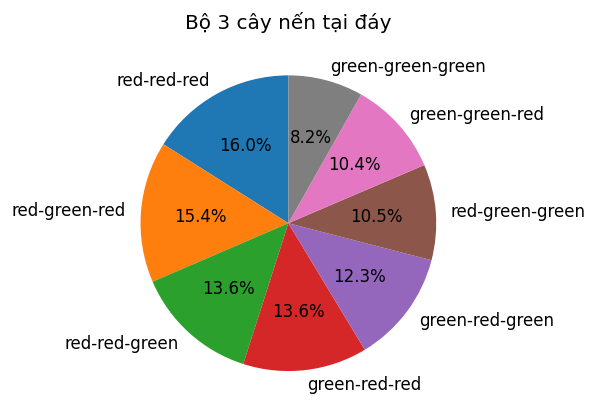

In [34]:
def group_3colors(r):
    return f'{r["_2bar_ago_color"]}-{r["prev_color"]}-{r["color"]}'

ana_data = ana_data[ana_data.color != 'doji']
ana_data['prev_color'] = ana_data['color'].shift(1)
ana_data['_2bar_ago_color'] = ana_data['color'].shift(2)
ana_data.dropna(inplace=True)
ana_data['_3bars_color_group'] = ana_data.apply(lambda r: group_3colors(r), axis=1)
counts = ana_data['_3bars_color_group'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Bộ 3 cây nến tại đáy")

### [✔] Tôi muốn biết vùng RSI nào hay gặp tại đáy?

Text(0.5, 1.0, 'Tỉ lệ vùng RSI khi tạo đáy')

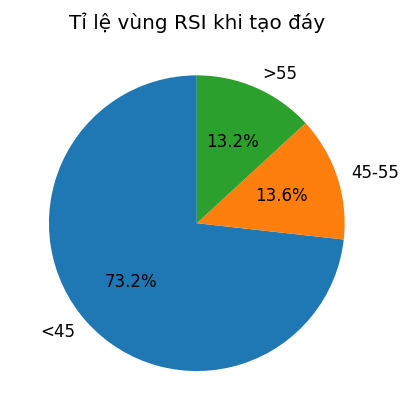

In [35]:
ana_data = merged_data.copy()
ana_data['RSI20'] = ta.rsi(ana_data["Close"], length=20)
ana_data['RSI10'] = ta.rsi(ana_data["Close"], length=10)
ana_data.dropna(inplace=True)
ana_data = ana_data[ana_data.Low == ana_data.DayLow]
ana_data['rsi_area'] = ana_data.apply(lambda r: '>55' if r["RSI20"] > 55 else ('<45' if r["RSI20"] < 45 else '45-55'), axis=1)
counts = ana_data['rsi_area'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ vùng RSI khi tạo đáy")

Text(0.5, 1.0, 'Tỉ lệ vùng RSI khi tạo đáy')

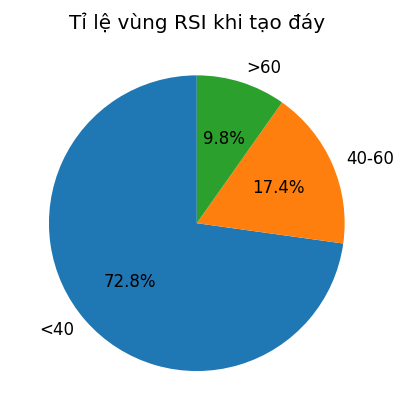

In [36]:
ana_data['rsi10_area'] = ana_data.apply(lambda r: '>60' if r["RSI10"] > 60 else ('<40' if r["RSI10"] < 40 else '40-60'), axis=1)
counts = ana_data['rsi10_area'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ vùng RSI khi tạo đáy")

### Tôi muốn biết bao nhiêu % xuất hiện FVG?

Text(0.5, 1.0, 'Tỉ lệ xuất hiện FVG khi tạo đáy')

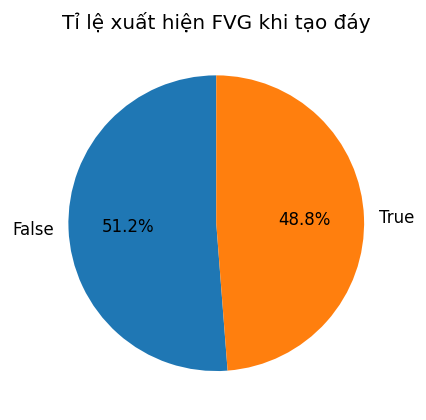

In [38]:
ana_data = merged_data.copy()
ana_data['is_FVG'] = ana_data["High"] < ana_data["Low"].shift(2)
ana_data.dropna(inplace=True)
ana_data = ana_data[ana_data.Low == ana_data.DayLow]
counts = ana_data['is_FVG'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ xuất hiện FVG khi tạo đáy")

### [✔] Tôi muốn biết bao nhiêu % Low giảm nhưng Volume giảm

Text(0.5, 1.0, 'Tỉ lệ (Low giảm nhưng Volume giảm) khi tạo đáy')

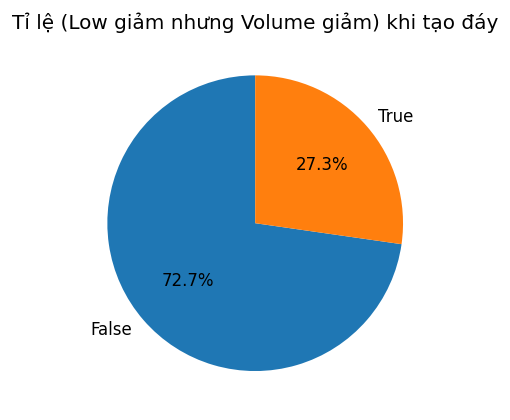

In [39]:
ana_data = merged_data.copy()
ana_data.dropna(inplace=True)
ana_data = ana_data[ana_data.Low == ana_data.DayLow]
ana_data['lower_low_lower_vol'] = ana_data.apply(lambda r: True if (r["Low"] < r["prev_Low"] and r["Volume"] < r["prev_Vol"]) else False, axis=1)
counts = ana_data['lower_low_lower_vol'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ (Low giảm nhưng Volume giảm) khi tạo đáy")

### [✔] Tôi muốn biết Volume thường cao hay thấp hơn Volume trung bình

Text(0.5, 1.0, 'Tỉ lệ Volume tăng so với TB khi tạo đáy')

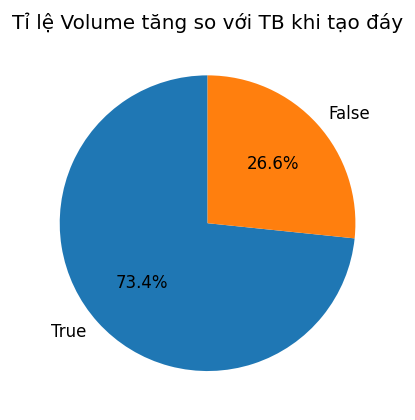

In [41]:
ana_data = merged_data.copy()
ana_data['avg_Volume'] = ana_data['Volume'].rolling(20).mean()
ana_data['Volume_higher_avg'] = ana_data.apply(lambda r: True if r["Volume"] > r["avg_Volume"] else False, axis=1)
ana_data = ana_data[ana_data.Low == ana_data.DayLow]
ana_data.dropna(inplace=True)
counts = ana_data['Volume_higher_avg'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ Volume tăng so với TB khi tạo đáy")

### [✔] Tôi muốn biết Volume thường cao hay thấp hơn Volume cây nến trước đó

Text(0.5, 1.0, 'Tỉ lệ Volume tăng/giảm so với cây nến trước đó khi tạo đáy')

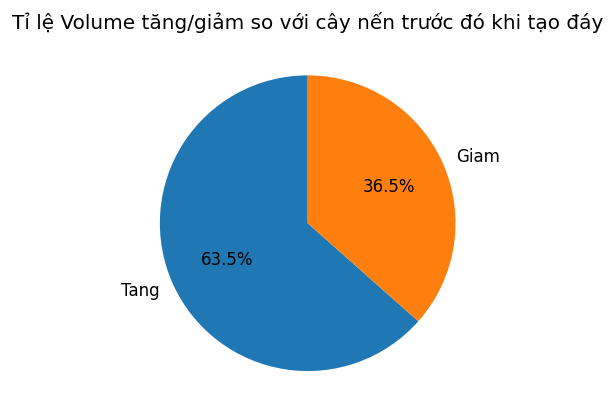

In [42]:
ana_data = merged_data.copy()
ana_data['Volume_vs_prev_Vol'] = ana_data.apply(lambda r: "Tang" if r["Volume"] > r["prev_Vol"] else "Giam", axis=1)
ana_data = ana_data[ana_data.Low == ana_data.DayLow]
ana_data.dropna(inplace=True)
counts = ana_data['Volume_vs_prev_Vol'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ Volume tăng/giảm so với cây nến trước đó khi tạo đáy")

### [✔] Tôi muốn biết Volume trung bình tăng hay giảm so với trước đó

Text(0.5, 1.0, 'Tỉ lệ Volume avg tăng / giảm so với trước đó khi tạo đỉnh')

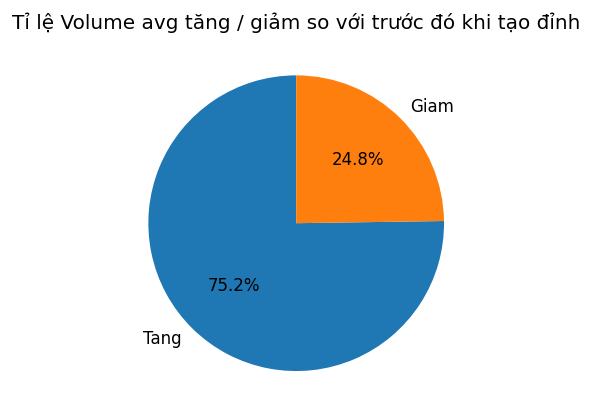

In [147]:
ana_data = merged_data.copy()
ana_data['Volume_avg'] = ana_data['Volume'].rolling(20).mean()
ana_data['prev_Volume_avg'] = ana_data['Volume_avg'].shift(1)
ana_data['Volume_avg_group'] = ana_data.apply(lambda r: "Tang" if r["Volume_avg"] > r["prev_Volume_avg"] else "Giam", axis=1)
ana_data = ana_data[ana_data.High == ana_data.DayHigh]
ana_data.dropna(inplace=True)
counts = ana_data['Volume_avg_group'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ Volume avg tăng / giảm so với trước đó khi tạo đáy")

### Tôi muốn biết bao nhiêu % Low giảm nhưng RSI giảm

Text(0.5, 1.0, 'Tỉ lệ Low giảm nhưng RSI giảm khi tạo đáy')

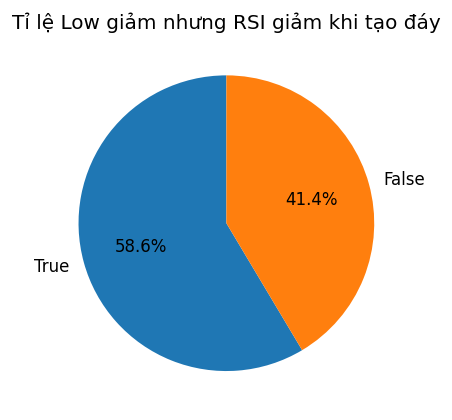

In [44]:
ana_data = merged_data.copy()
ana_data['RSI24'] = ta.rsi(ana_data["Close"], length=24)
ana_data['prev_RSI24'] = ana_data['RSI24'].shift(1)
ana_data.dropna(inplace=True)
ana_data = ana_data[ana_data.Low == ana_data.DayLow] 
ana_data['low_and_rsi_group'] = ana_data.apply(lambda r: True if (r["Low"] < r["prev_Low"] and r["RSI24"] < r["prev_RSI24"]) else False, axis=1)
ana_data.dropna(inplace=True)
counts = ana_data['low_and_rsi_group'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ Low giảm nhưng RSI giảm khi tạo đáy")

### [✔] Tôi muốn biết giá Close thường nằm ở vị trí nào?

Text(0.5, 1.0, 'Tỉ lệ vi tri gia Close(so voi cay nen truoc do) khi tạo đáy')

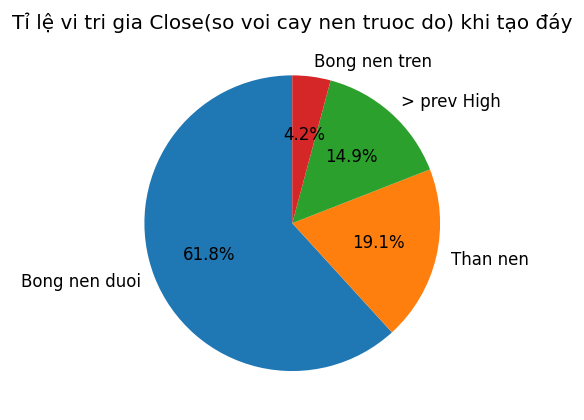

In [45]:
def get_close_price_position(r):
    if r["Close"] > r["prev_High"]:
        return "> prev High"
    if r["Close"] > max(r["prev_Close"], r["prev_Open"]):
        return "Bong nen tren "
    if max(r["prev_Close"], r["prev_Open"]) > r["Close"] > min(r["prev_Close"], r["prev_Open"]):
        return "Than nen"
    if r["Close"] < min(r["prev_Close"], r["prev_Open"]):
        return "Bong nen duoi"
    if r["Close"] < r["prev_Low"]:
        return "< prev Low"  
ana_data = merged_data.copy()
ana_data = ana_data[ana_data.Low == ana_data.DayLow]
ana_data['close_price_group'] = ana_data.apply(lambda r: get_close_price_position(r), axis=1)
ana_data.dropna(inplace=True)
counts = ana_data['close_price_group'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ vi tri gia Close(so voi cay nen truoc do) khi tạo đáy")

### [✔] Tôi muốn biết giá vị trí giá Open ở  đâu so với Close trước đó?

Text(0.5, 1.0, 'Tỉ lệ vi tri gia Open(so voi Close truoc do) khi tạo đáy')

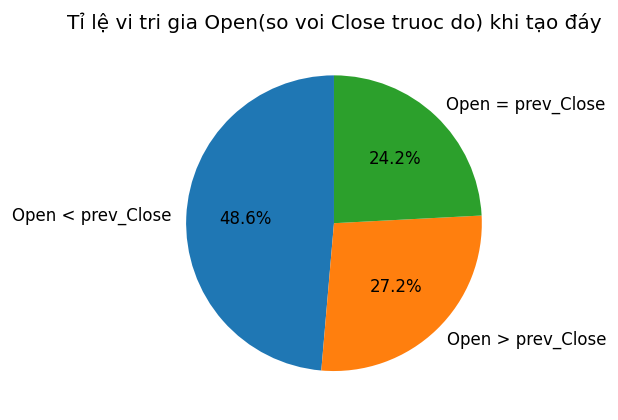

In [46]:
def get_open_price_position(r):
    if r["Open"] > r["prev_Close"]:
        return "Open > prev_Close"
    if r["Open"] == r["prev_Close"]:
        return "Open = prev_Close"
    if r["Open"] < r["prev_Close"]:
        return "Open < prev_Close"
ana_data = merged_data.copy()
ana_data = ana_data[ana_data.Low == ana_data.DayLow]
ana_data['opene_price_group'] = ana_data.apply(lambda r: get_open_price_position(r), axis=1)
ana_data.dropna(inplace=True)
counts = ana_data['opene_price_group'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ vi tri gia Open(so voi Close truoc do) khi tạo đáy")

### [✔] Tôi muốn biết giá Low so với Lower_Bollinger_Band thế nào?

Text(0.5, 1.0, 'Tỉ lệ (Low nằm trên/dưới đường lower BB) khi tạo đáy')

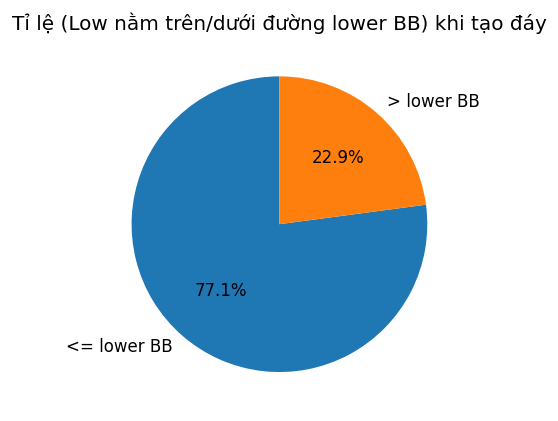

In [48]:
ana_data = merged_data.copy()
ana_data["MB"] = ana_data["Close"].rolling(20).mean()
ana_data["STD"] = ana_data["Close"].rolling(20).std()
ana_data["LB"] = ana_data["MB"] - 1.5 * ana_data["STD"]
ana_data = ana_data[ana_data.Low == ana_data.DayLow] 
ana_data['Low_position'] = ana_data.apply(lambda r: '> lower BB' if r["Low"] > r["LB"] else '<= lower BB', axis=1)
ana_data.dropna(inplace=True)
counts = ana_data['Low_position'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ (Low nằm trên/dưới đường lower BB) khi tạo đáy")

### Tôi muốn biết có hiện tượng "Bollinger rejection" hay không?

Text(0.5, 1.0, 'Tỉ lệ Bollinger rejection khi tạo đáy')

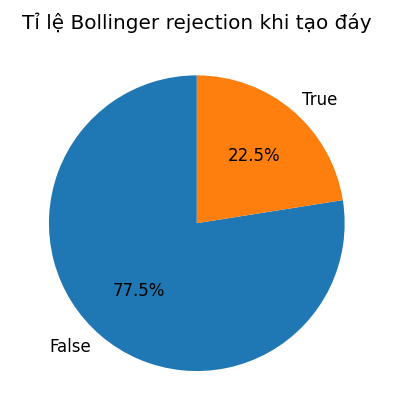

In [49]:
# Giá xuyên band nhưng đóng bên trong → Bollinger rejection
ana_data = ana_data[ana_data.Low_position == '<= lower BB']
ana_data["BB_rejection"] = ana_data.apply(lambda r: True if r["Close"] > r["LB"] else False, axis=1)
ana_data.dropna(inplace=True)
counts = ana_data['BB_rejection'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Tỉ lệ Bollinger rejection khi tạo đáy")